In [1]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

In [2]:
def find_ecg_records(root_dir):
    records = []
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.endswith(".hea"):
                record_name = f.replace(".hea", "")
                records.append(os.path.join(root, record_name))
    return records


In [3]:
def print_ecg_info(record):
    sig, fields = wfdb.rdsamp(record)

    fs = fields['fs']
    n_samples = sig.shape[0]
    n_leads = sig.shape[1]
    duration_sec = n_samples / fs

    print("=" * 60)
    print(f"Record           : {os.path.basename(record)}")
    print(f"Sampling Rate    : {fs} Hz")
    print(f"Leads            : {n_leads}")
    print(f"Duration         : {duration_sec:.2f} sec ({timedelta(seconds=duration_sec)})")
    print("Lead Names       :", fields['sig_name'])
    print("Units            :", fields['units'])
    print("=" * 60)

    return sig, fields


In [4]:
def plot_ecg_overview(sig, fields, seconds=10):
    fs = fields['fs']
    lead_names = fields['sig_name']

    samples = int(seconds * fs)
    t = np.arange(samples) / fs

    plt.figure(figsize=(14, 10))
    for i in range(sig.shape[1]):
        plt.plot(t, sig[:samples, i] + i * 2, label=lead_names[i])

    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV, offset per lead)")
    plt.title("12-Lead ECG Overview")
    plt.legend(loc="upper right", ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [5]:
def plot_ecg_with_timestamps(sig, fields, lead="II", start_sec=0, window_sec=5):
    fs = fields['fs']
    lead_idx = fields['sig_name'].index(lead)

    start = int(start_sec * fs)
    end = int((start_sec + window_sec) * fs)

    t = np.arange(start, end) / fs

    plt.figure(figsize=(14, 4))
    plt.plot(t, sig[start:end, lead_idx])
    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (mV)")
    plt.title(f"ECG Lead {lead} | {window_sec}s window")
    plt.grid(True)
    plt.show()


### Checking how the data looks for the first 5 ECG fields

Record           : 42546971
Sampling Rate    : 500 Hz
Leads            : 12
Duration         : 10.00 sec (0:00:10)
Lead Names       : ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units            : ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


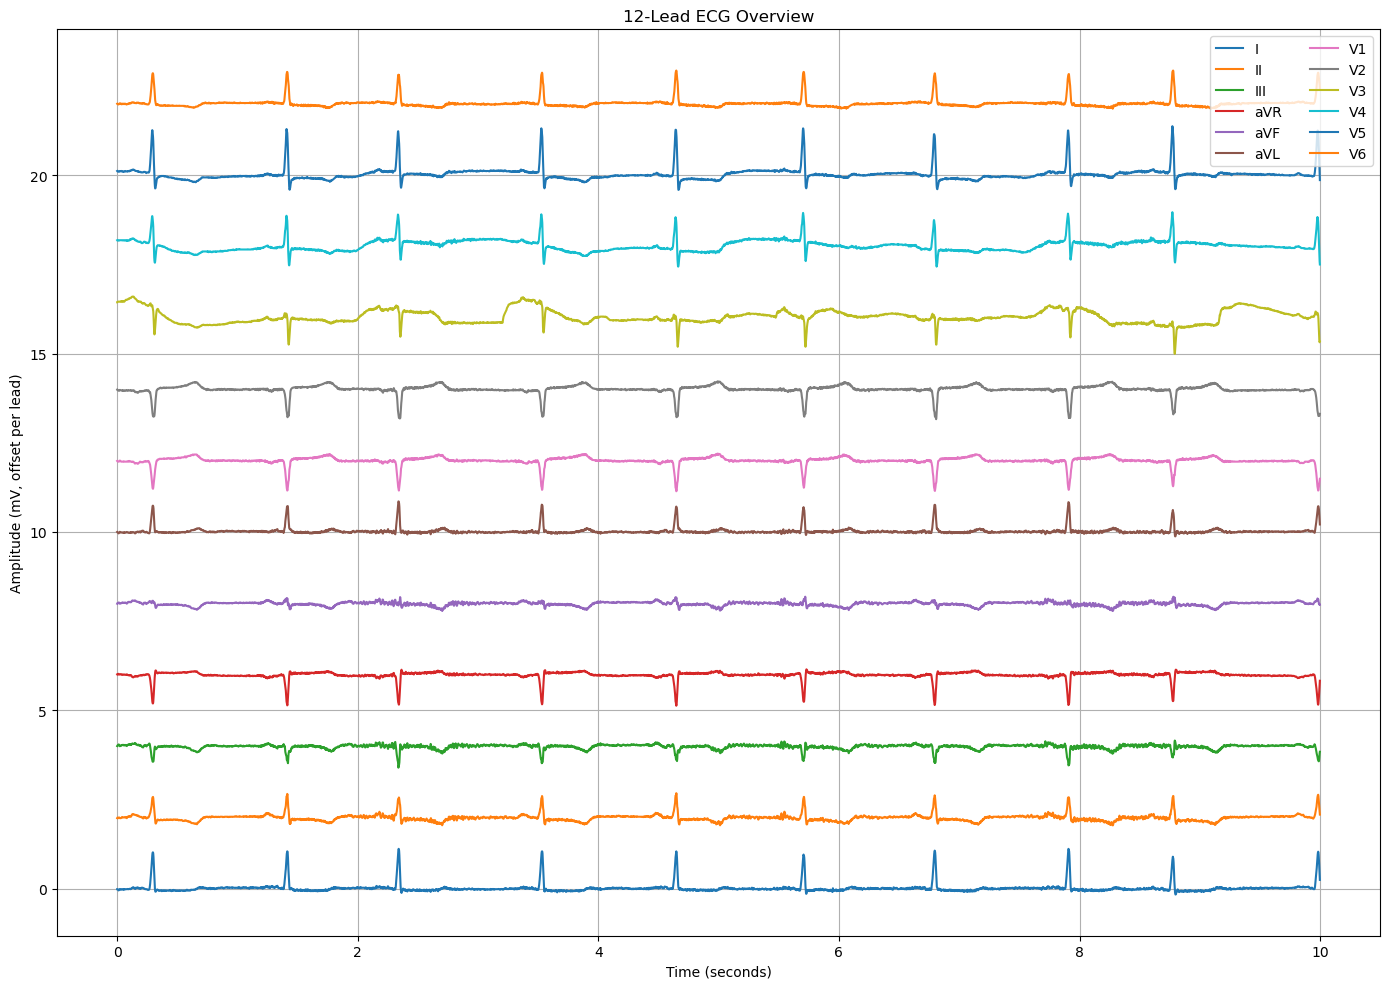

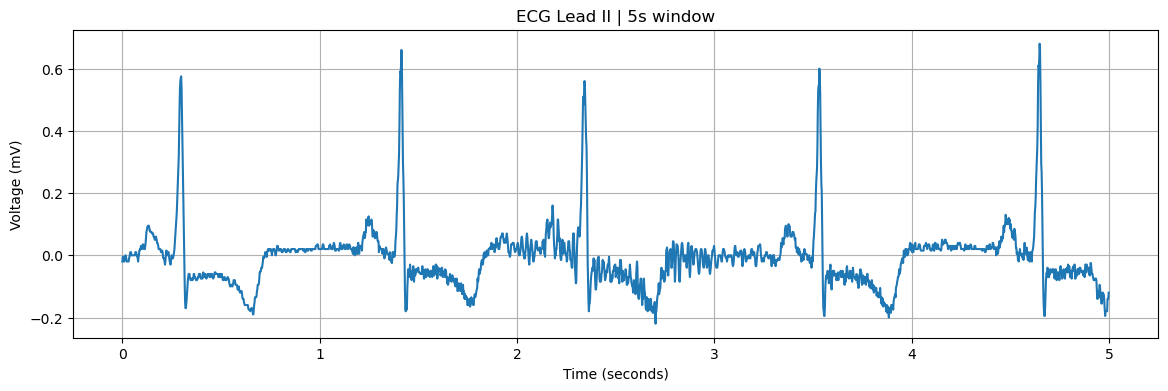

Record           : 46167614
Sampling Rate    : 500 Hz
Leads            : 12
Duration         : 10.00 sec (0:00:10)
Lead Names       : ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units            : ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


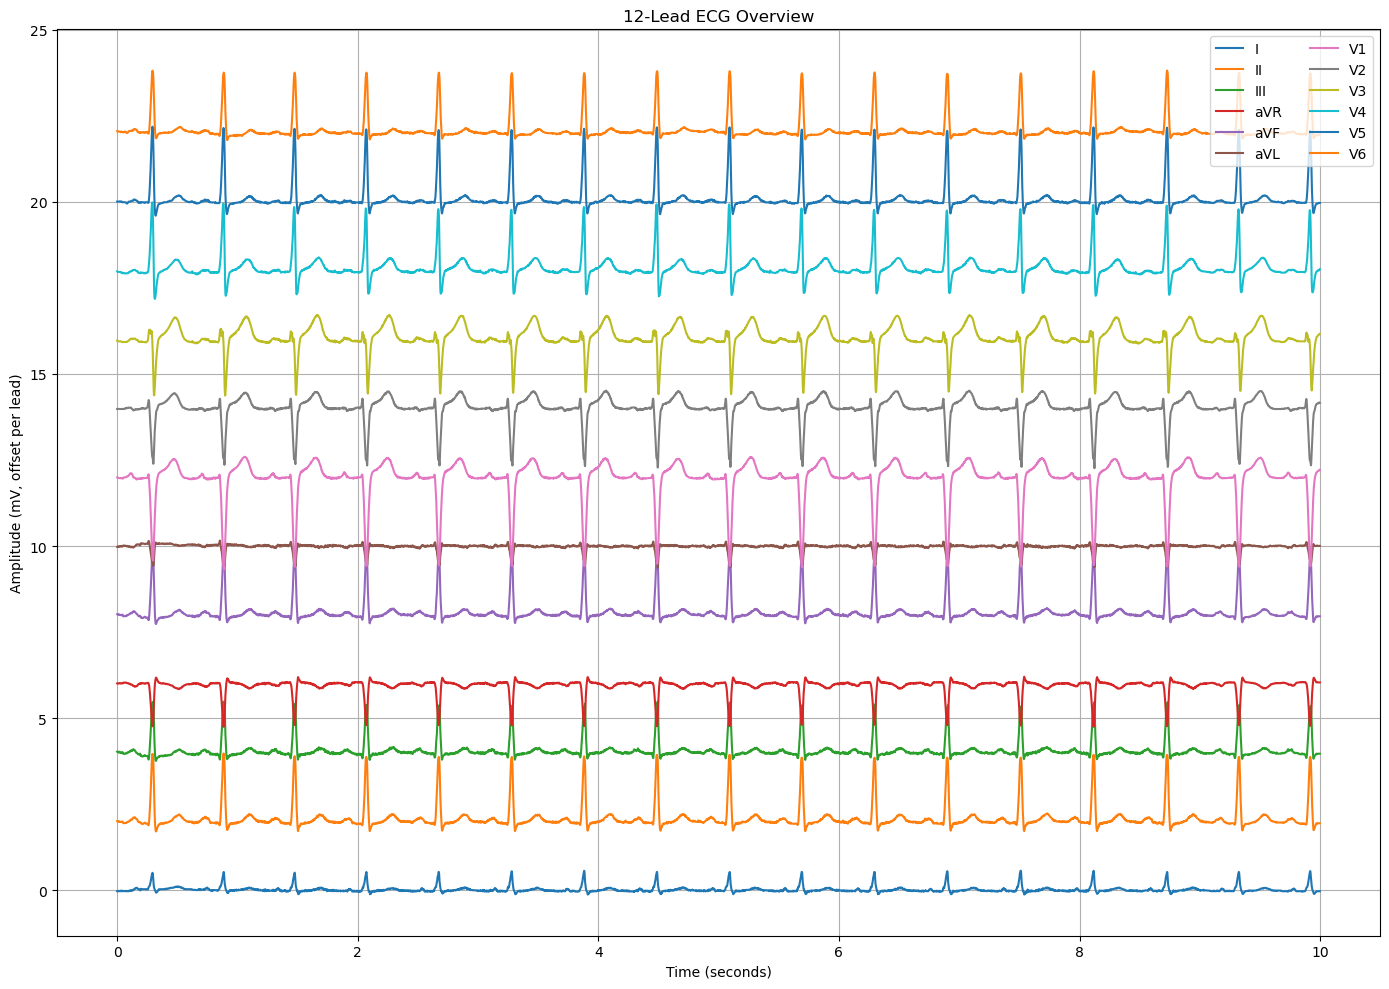

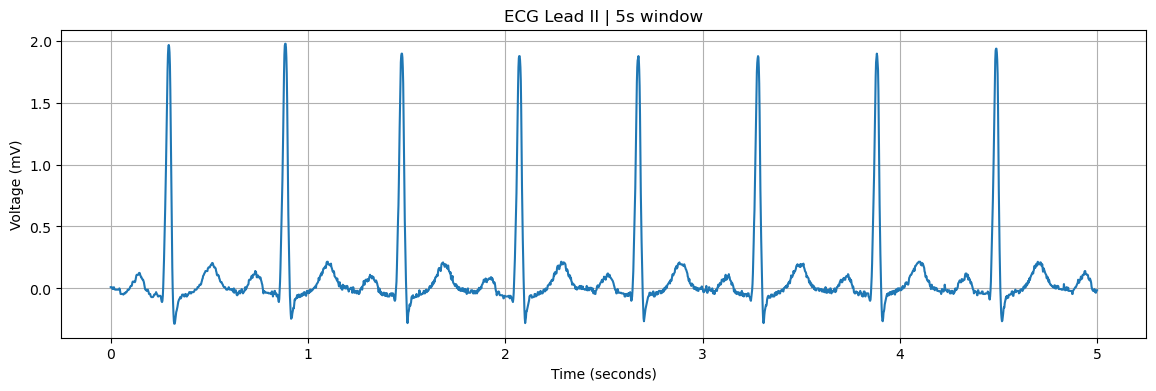

Record           : 47527771
Sampling Rate    : 500 Hz
Leads            : 12
Duration         : 10.00 sec (0:00:10)
Lead Names       : ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units            : ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


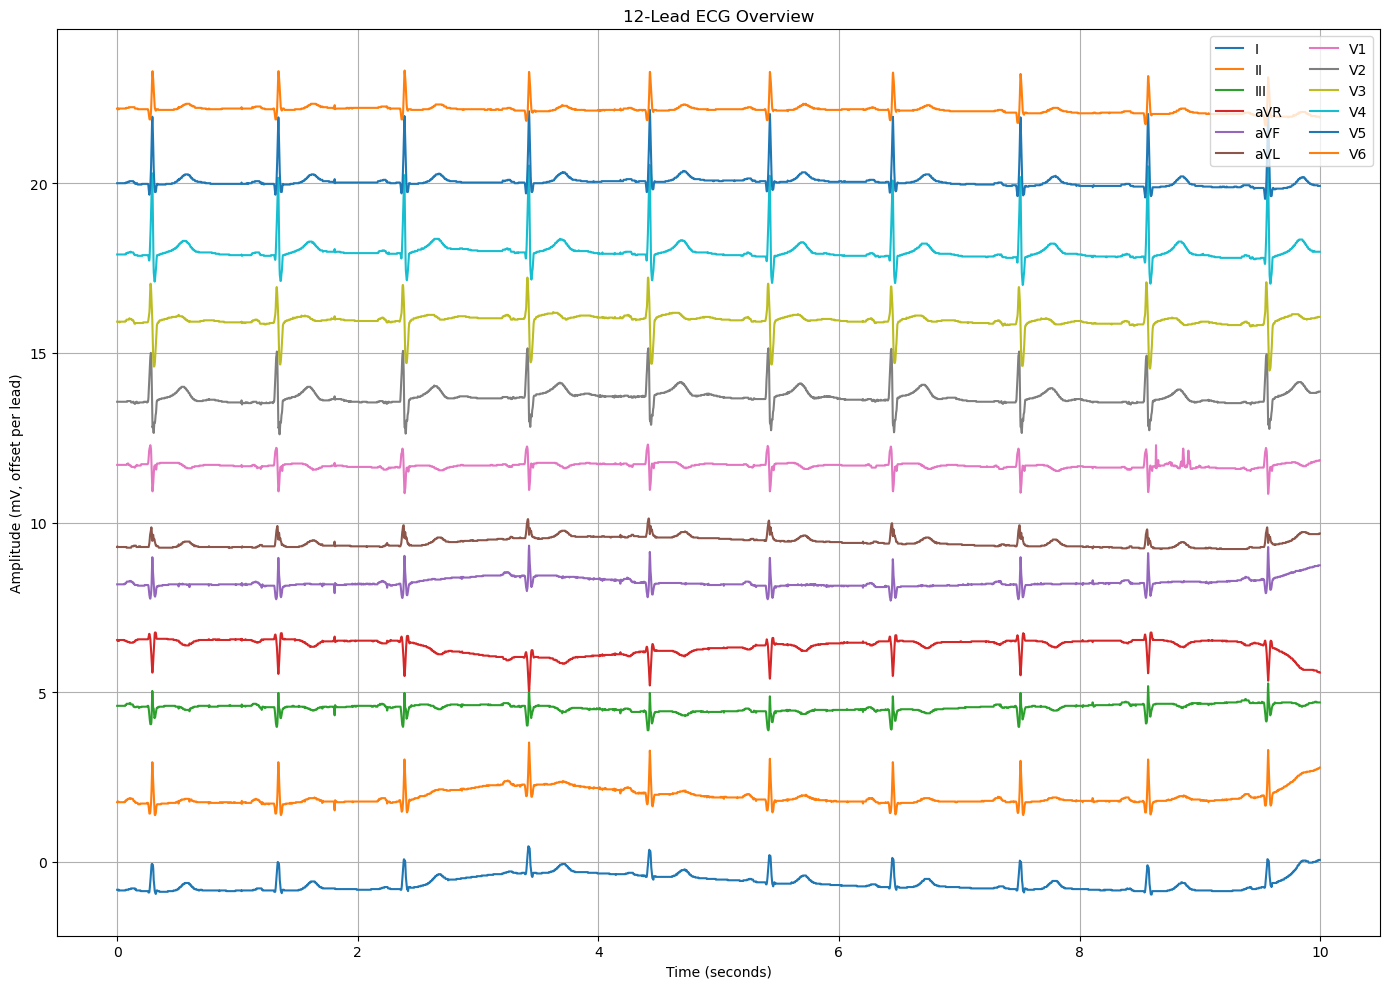

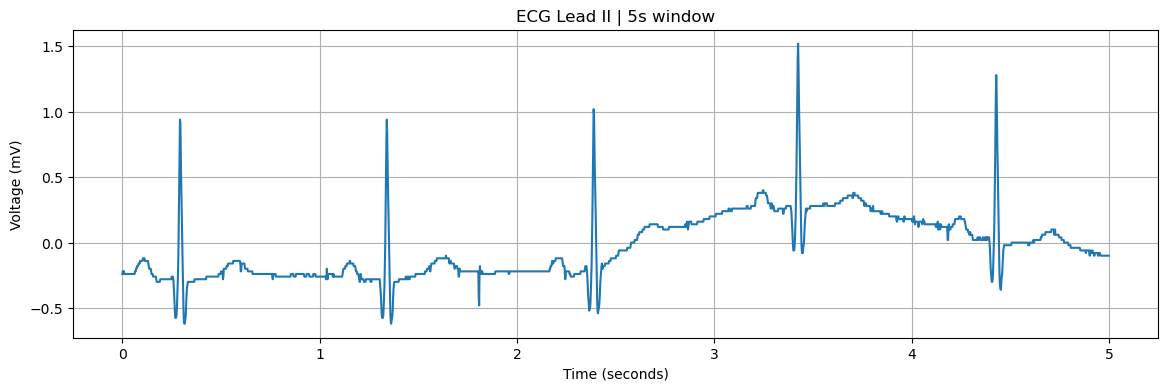

Record           : 45298707
Sampling Rate    : 500 Hz
Leads            : 12
Duration         : 10.00 sec (0:00:10)
Lead Names       : ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units            : ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


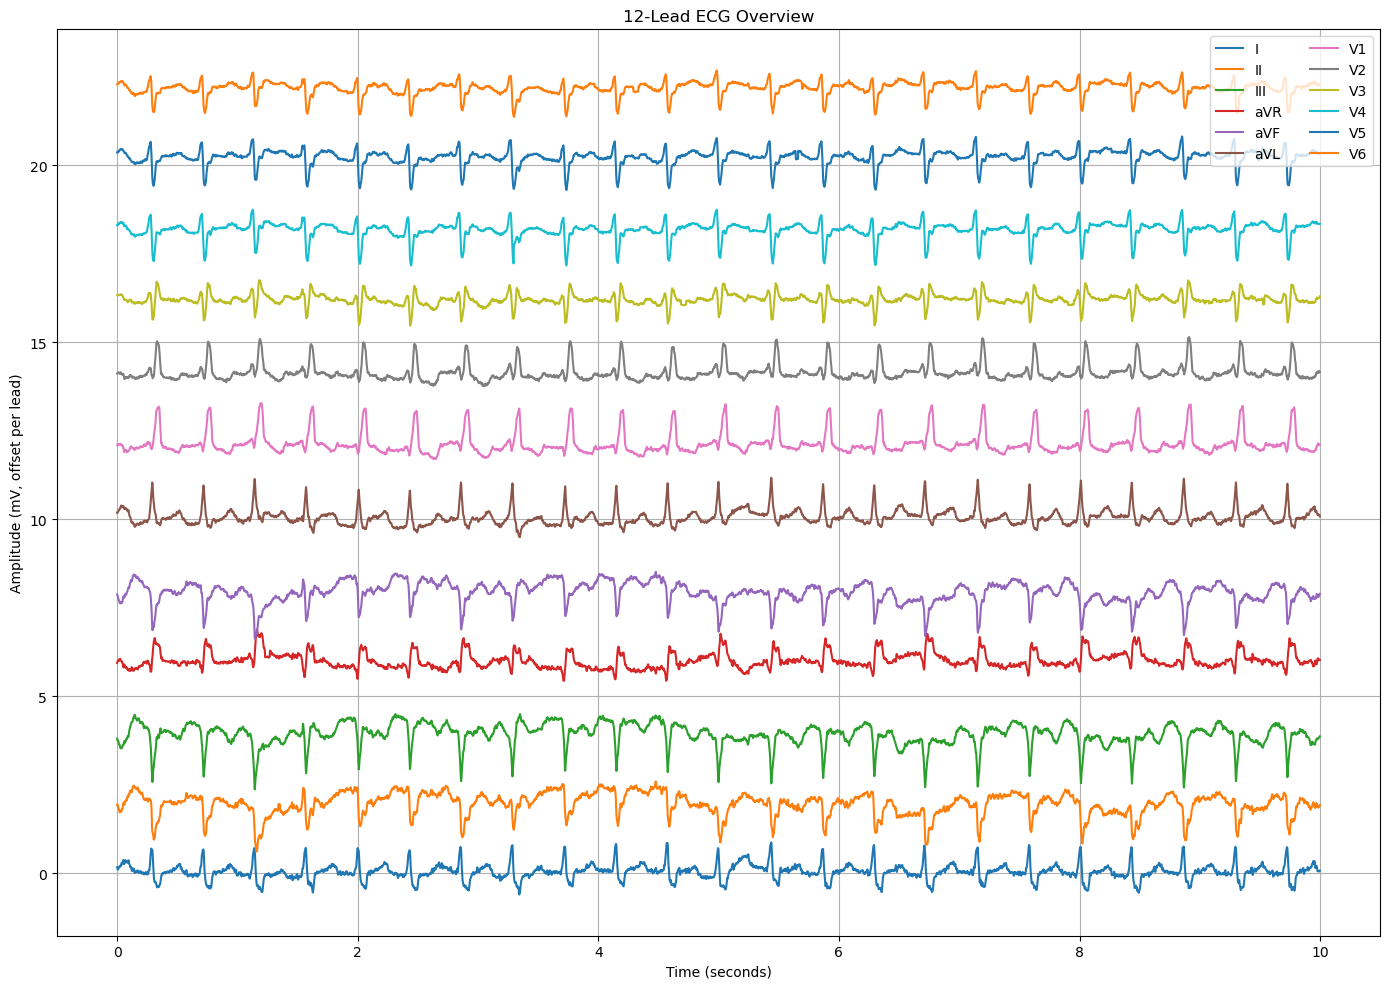

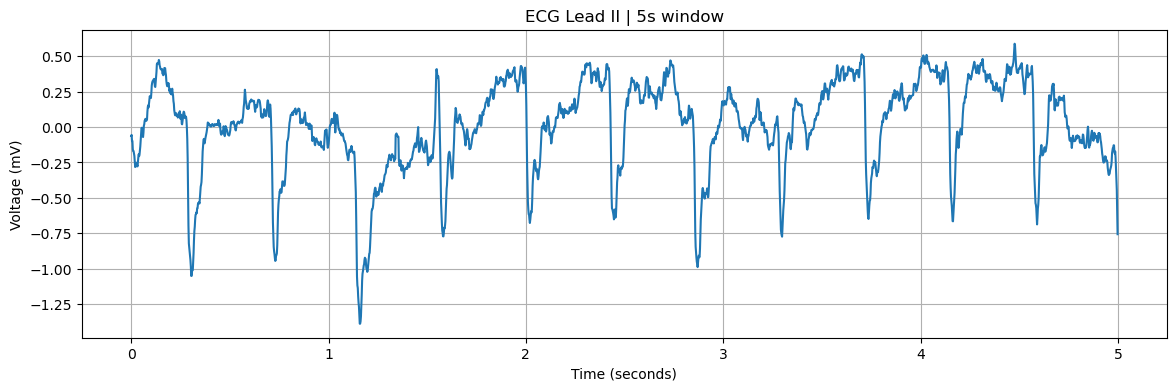

Record           : 42706520
Sampling Rate    : 500 Hz
Leads            : 12
Duration         : 10.00 sec (0:00:10)
Lead Names       : ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units            : ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


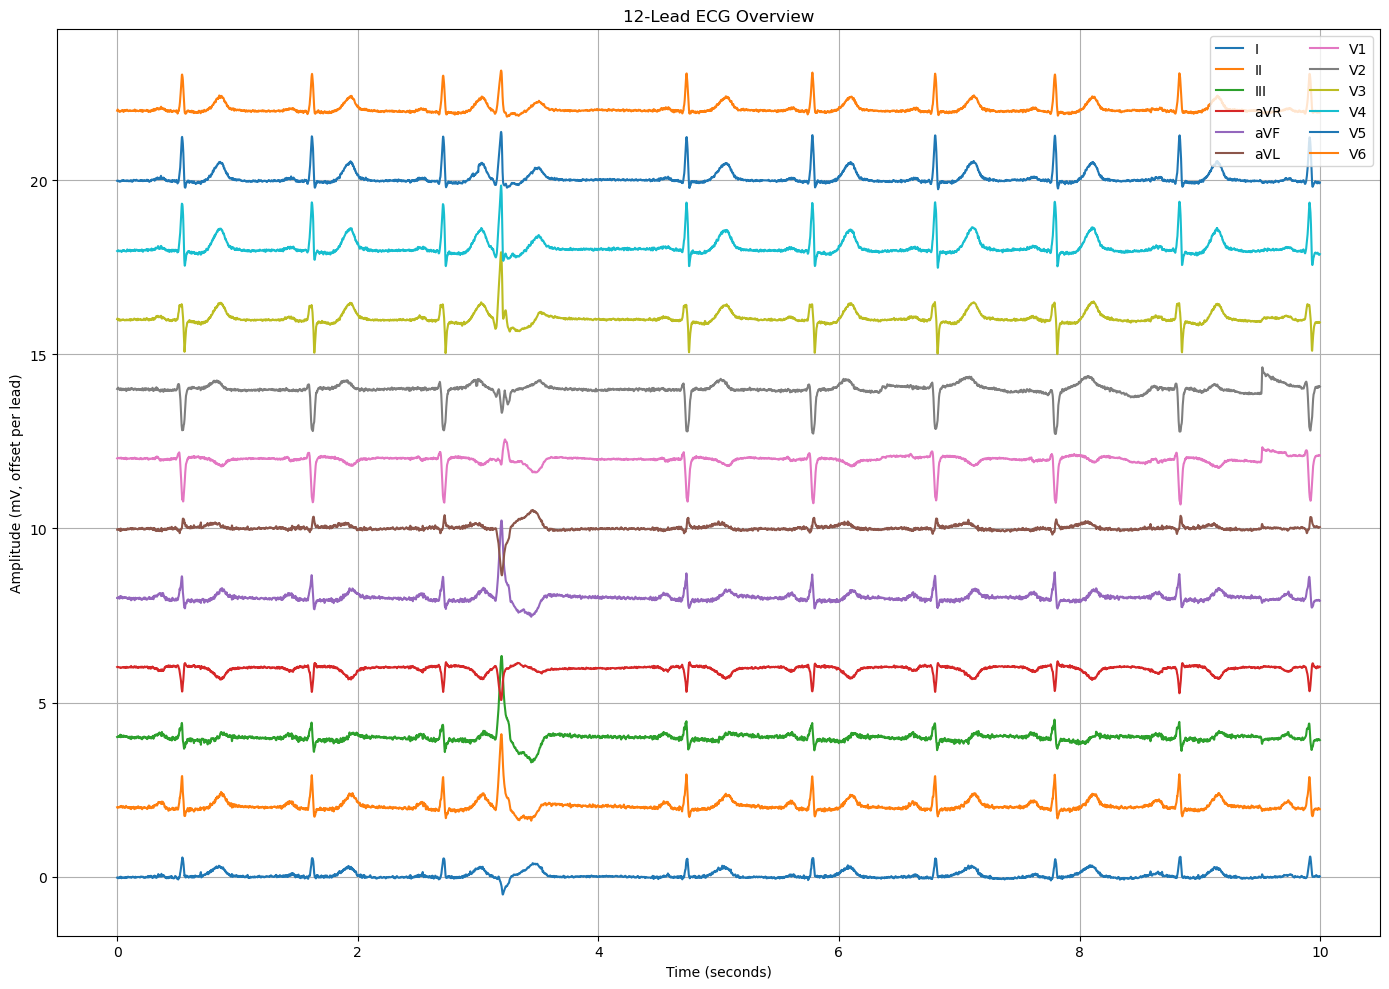

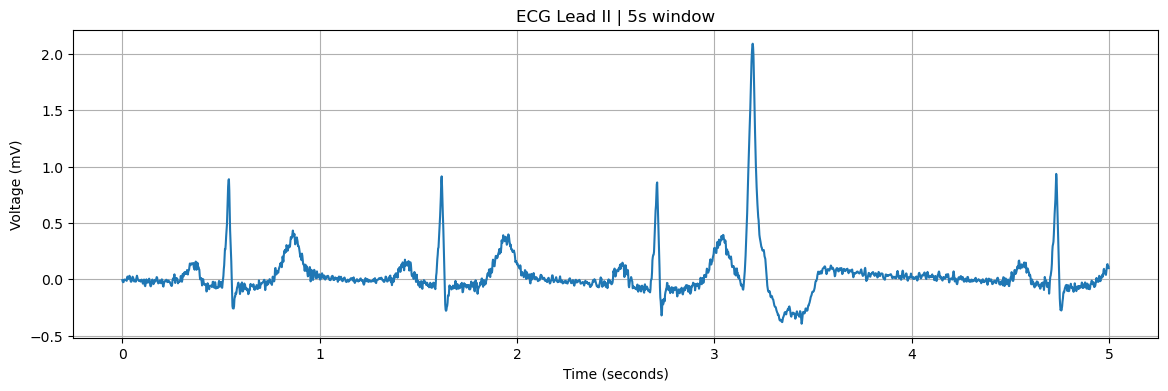

In [ ]:
root_folder = "time-series-project2025"

records = find_ecg_records(root_folder)

num_records = 5

for record in records[:num_records]:
    sig, fields = print_ecg_info(record)

    # Visualization
    plot_ecg_overview(sig, fields, seconds=10)
    plot_ecg_with_timestamps(sig, fields, lead="II", start_sec=0, window_sec=5)
